# Phase 2 — Exploratory Data Analysis
**Project:** Dubai Apartment Rent Predictor  
**Input:** `dubai_clean.csv` from Phase 1  
**Goal:** Understand the data well enough to make smart modelling decisions

### What this notebook answers
1. What does the Rent distribution look like — and should we log-transform it?
2. Which numeric features (beds, baths, area) correlate most with Rent?
3. Which locations command the highest rents?
4. Do furnished apartments cost significantly more?
5. Which features should go into the model?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.float_format', '{:,.0f}'.format)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# UPDATE this path to match where you saved dubai_clean.csv
CLEAN_PATH = r'C:\Users\ashly\Real Estate Predictor\dubai_clean.csv'

df = pd.read_csv(CLEAN_PATH)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Loaded: 73,072 rows, 21 columns


,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,...,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude,Beds_x_Baths,Posted_month,Posted_year,Is_furnished
0,"The Gate Tower 2, The Gate Tower, Shams Gate D...",124000,3,4,apartment,1785,69,Medium,yearly,unfurnished,...,2024-03-07,45,Al Reem Island,abu dhabi,24,54,12,3,2024,0
1,"Water's Edge, Yas Island, Abu Dhabi",140000,3,4,apartment,1422,98,Medium,yearly,unfurnished,...,2024-03-08,44,Yas Island,abu dhabi,24,55,12,3,2024,0
2,"Al Raha Lofts, Al Raha Beach, Abu Dhabi",99000,2,3,apartment,1314,75,Medium,yearly,furnished,...,2024-03-21,31,Al Raha Beach,abu dhabi,24,55,6,3,2024,1
3,"Marina Heights, Marina Square, Al Reem Island,...",220000,3,4,penthouse,3843,57,High,yearly,unfurnished,...,2024-02-24,57,Al Reem Island,abu dhabi,24,54,12,2,2024,0
4,"West Yas, Yas Island, Abu Dhabi",350000,5,7,villa,6860,51,High,yearly,unfurnished,...,2024-02-16,65,Yas Island,abu dhabi,24,55,35,2,2024,0


---
## 1. Rent distribution

First thing to check for any regression target: is it normally distributed?  
If it's heavily right-skewed, a log-transform often improves model performance  
because most ML models assume errors are normally distributed.

> **Interview talking point:** Log-transforming the target compresses the range of large values,  
> reduces the influence of high-rent outliers, and often gives you a better R² score.  
> You transform before training and inverse-transform predictions back to AED for display.

In [3]:
print('Rent summary statistics:')
print(df['Rent'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f'\nSkewness: {df["Rent"].skew():.2f}  (>1 = right skewed, consider log transform)')

Rent summary statistics:
count      73,072
mean      132,202
std       122,433
min        10,000
25%        54,990
50%        95,000
75%       165,000
90%       265,000
95%       360,000
99%       650,000
max     1,000,000
Name: Rent, dtype: float64

Skewness: 2.81  (>1 = right skewed, consider log transform)


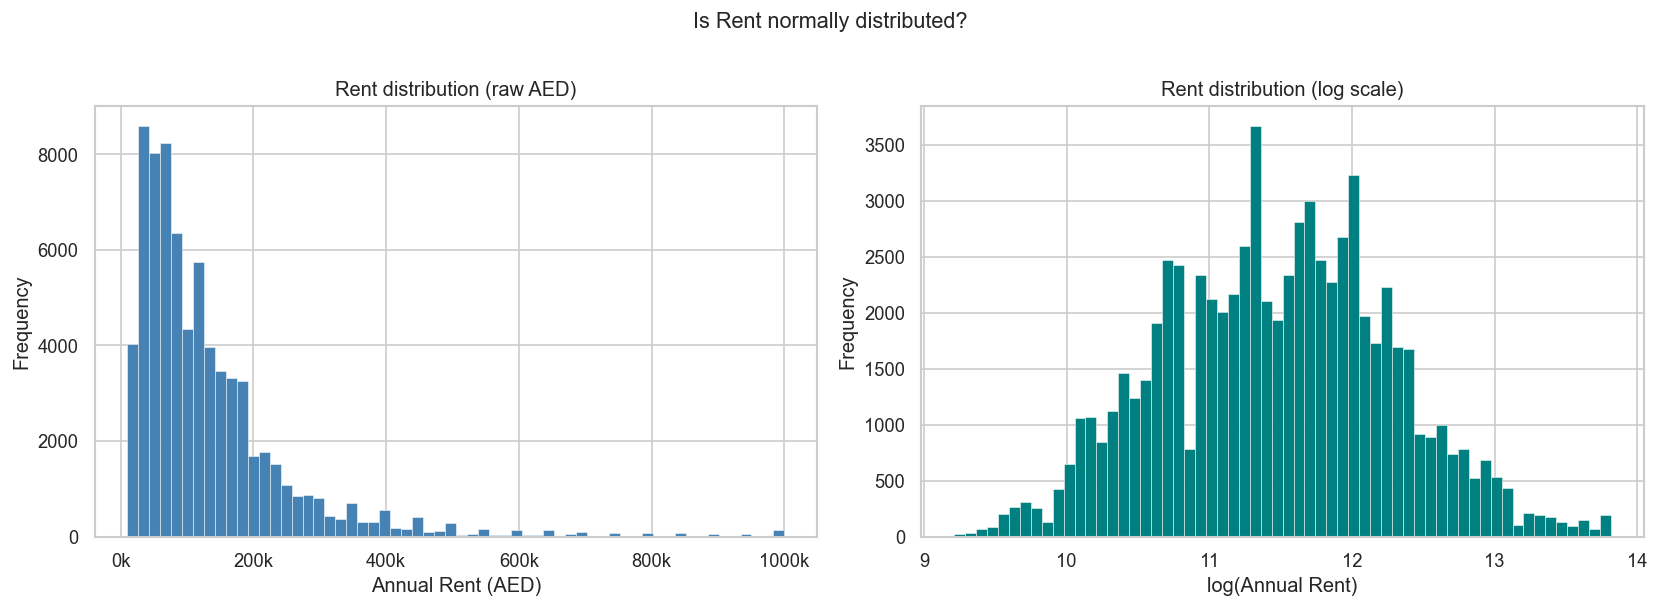

Skewness = 2.81 → RIGHT SKEWED. Use log(Rent) as the model target.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Rent
axes[0].hist(df['Rent'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Rent distribution (raw AED)')
axes[0].set_xlabel('Annual Rent (AED)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Log-transformed Rent
axes[1].hist(np.log(df['Rent']), bins=60, color='teal', edgecolor='white', linewidth=0.3)
axes[1].set_title('Rent distribution (log scale)')
axes[1].set_xlabel('log(Annual Rent)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Is Rent normally distributed?', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_01_rent_distribution.png', bbox_inches='tight')
plt.show()

# Decision
skew = df['Rent'].skew()
if skew > 1:
    print(f'Skewness = {skew:.2f} → RIGHT SKEWED. Use log(Rent) as the model target.')
else:
    print(f'Skewness = {skew:.2f} → Roughly normal. Raw Rent is fine as the model target.')

In [20]:
# Add log_rent column — we will use this as the model target in Phase 3
df['log_Rent'] = np.log(df['Rent'])
print(df['log_Rent'].describe())

count   73,072
mean        11
std          1
min          9
25%         11
50%         11
75%         12
max         14
Name: log_Rent, dtype: float64


---
## 2. Numeric features vs Rent

We want to know: which numeric features have a strong relationship with Rent?  
Strong correlation = useful predictor. Weak correlation = may not help the model.

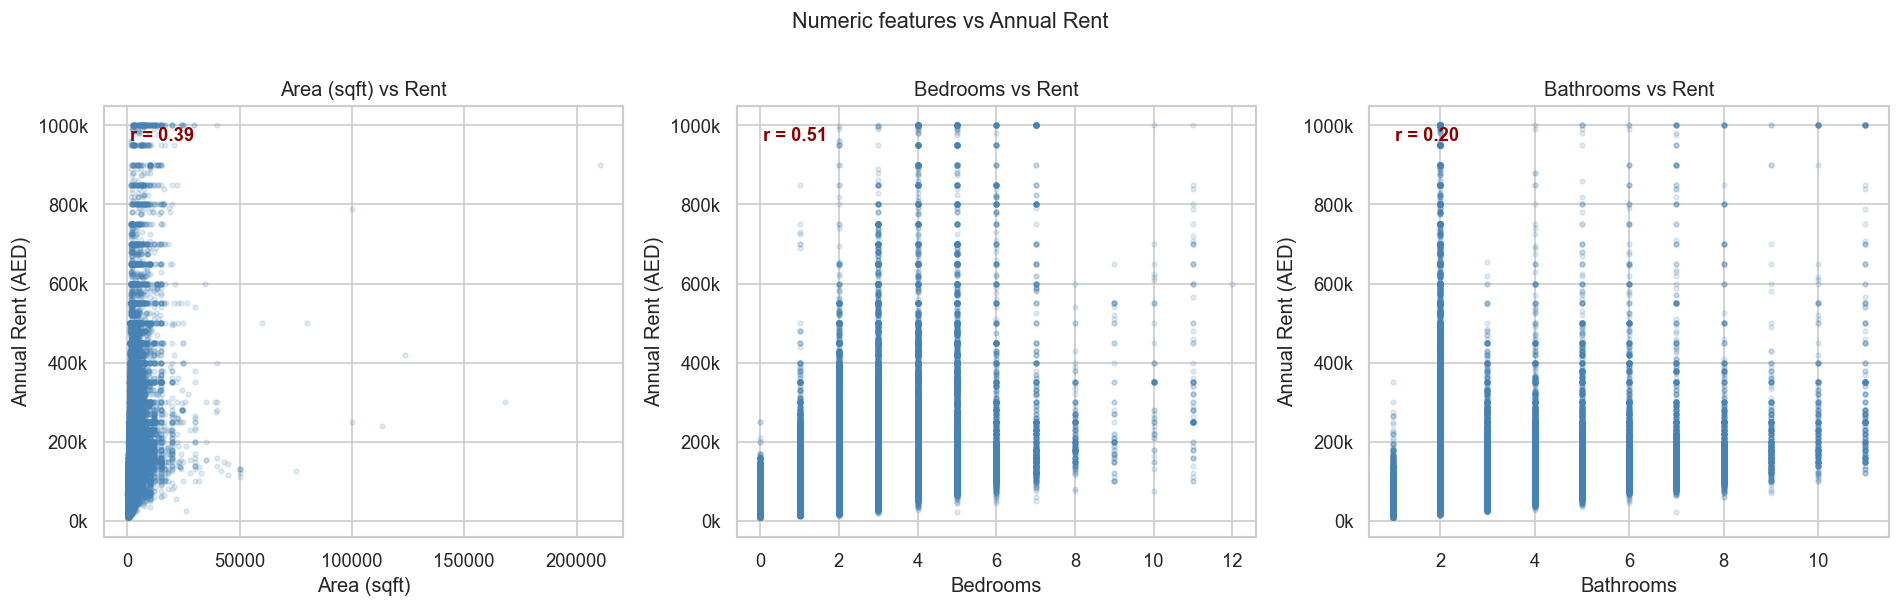

In [6]:
# Scatter plots: Area, Beds, Baths vs Rent
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('Area_in_sqft', 'Area (sqft)'),
    ('Beds', 'Bedrooms'),
    ('Baths', 'Bathrooms'),
]

for ax, (col, label) in zip(axes, pairs):
    ax.scatter(df[col], df['Rent'], alpha=0.15, s=8, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Annual Rent (AED)')
    ax.set_title(f'{label} vs Rent')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    corr = df[col].corr(df['Rent'])
    ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11,
                color='darkred', fontweight='bold')

plt.suptitle('Numeric features vs Annual Rent', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_02_numeric_vs_rent.png', bbox_inches='tight')
plt.show()

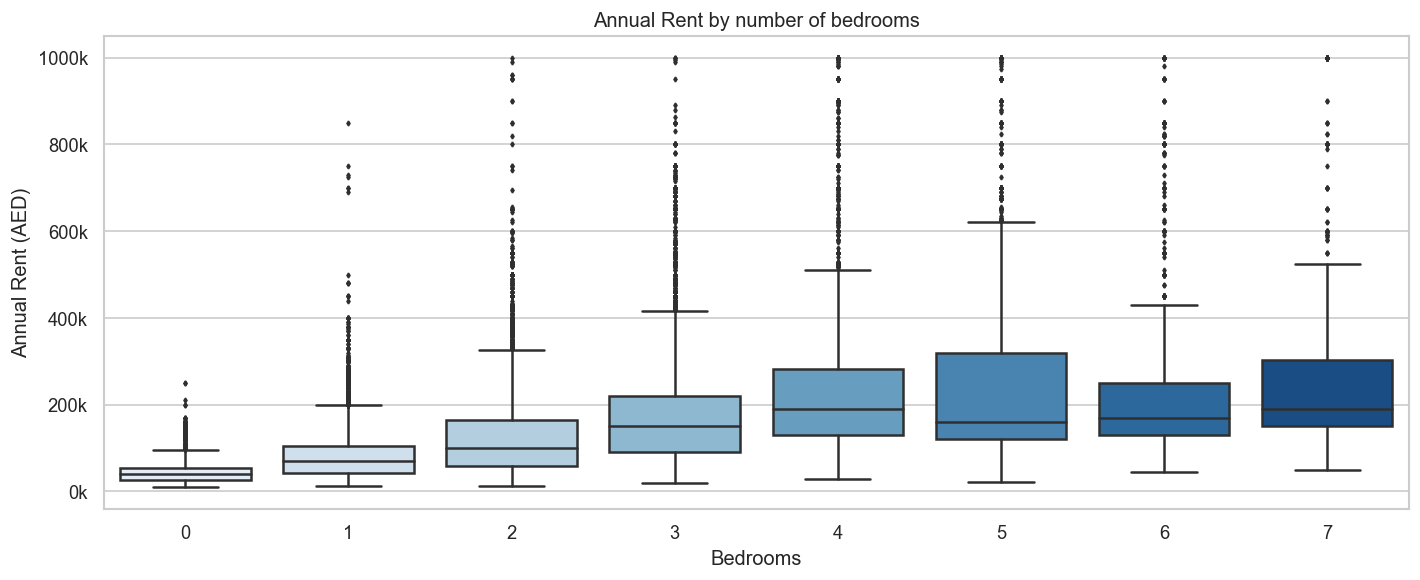

In [7]:
# Boxplot: Rent by number of bedrooms
# This shows median rent and spread for each bedroom count
fig, ax = plt.subplots(figsize=(12, 5))

bed_order = sorted(df['Beds'].dropna().unique())
# Cap at 7 beds for readability — very few listings above this
bed_order = [b for b in bed_order if b <= 7]
plot_df = df[df['Beds'].isin(bed_order)]

sns.boxplot(data=plot_df, x='Beds', y='Rent', order=bed_order,
            palette='Blues', fliersize=2, ax=ax)
ax.set_title('Annual Rent by number of bedrooms')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Annual Rent (AED)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('eda_03_rent_by_beds.png', bbox_inches='tight')
plt.show()

---
## 3. Location analysis

Location is typically the most powerful predictor in real estate models.  
We plot the top 20 locations by median rent — this also tells us which  
locations have enough data to be reliable in the model.

> **Interview talking point:** We use median (not mean) because it's robust to outliers.  
> A single luxury penthouse in a location with 3 listings would skew the mean dramatically.

In [8]:
# How many unique locations are there?
print(f'Unique locations: {df["Location"].nunique()}')
print(f'\nTop 10 locations by listing count:')
print(df['Location'].value_counts().head(10))

Unique locations: 440

Top 10 locations by listing count:
Location
Al Reem Island                   3668
Jumeirah Village Circle (JVC)    3117
Downtown Dubai                   2978
Khalifa City                     2748
Dubai Marina                     2575
Business Bay                     2147
Muwailih Commercial              2055
Mohammed Bin Zayed City          2050
Al Raha Beach                    1808
Dubai Creek Harbour              1735
Name: count, dtype: int64


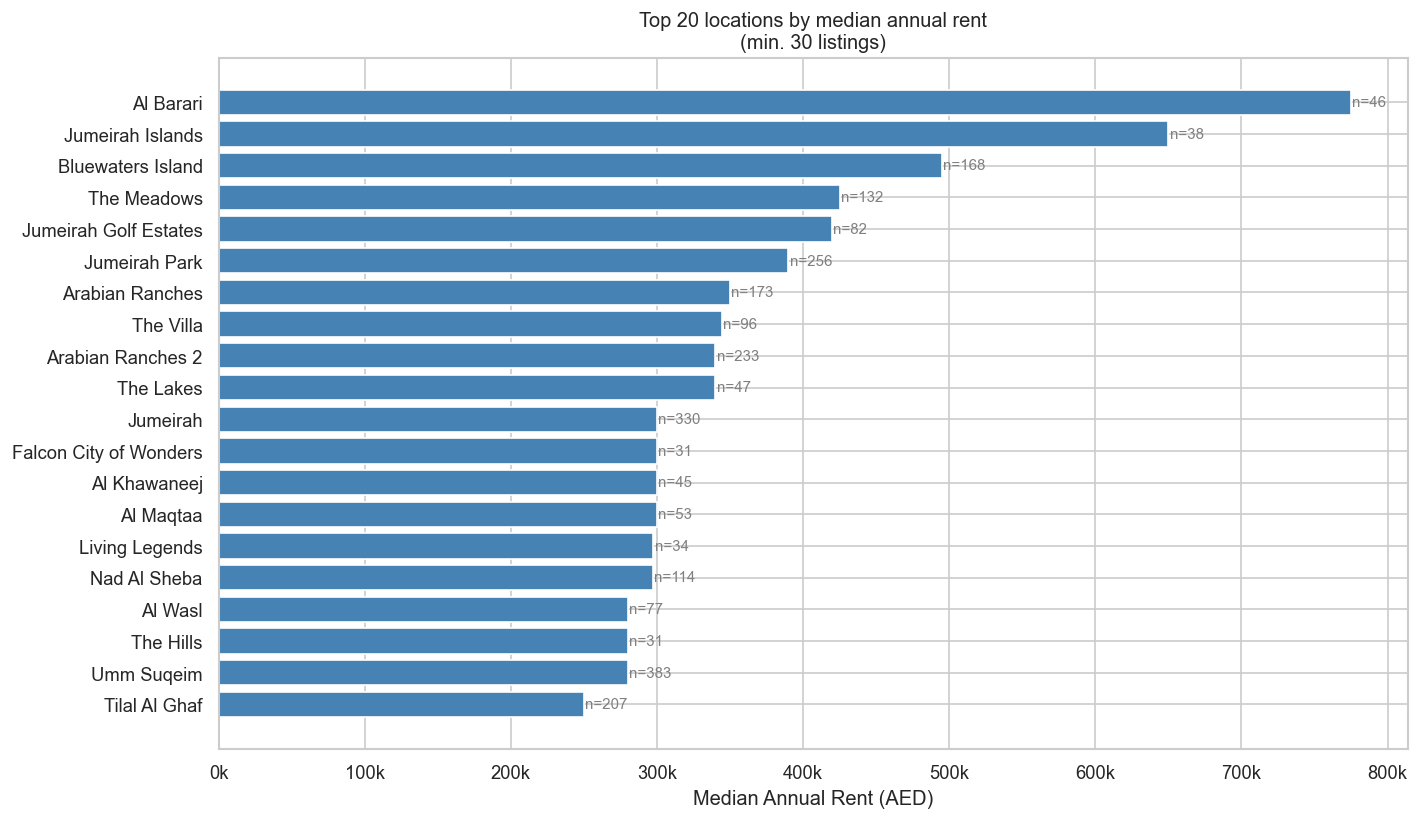

              Location  median_rent  count
             Al Barari      775,000     46
      Jumeirah Islands      650,000     38
     Bluewaters Island      495,000    168
           The Meadows      425,000    132
 Jumeirah Golf Estates      419,500     82
         Jumeirah Park      390,000    256
       Arabian Ranches      350,000    173
             The Villa      344,500     96
     Arabian Ranches 2      340,000    233
             The Lakes      340,000     47
              Jumeirah      300,000    330
Falcon City of Wonders      300,000     31
          Al Khawaneej      300,000     45
             Al Maqtaa      299,999     53
        Living Legends      297,500     34
          Nad Al Sheba      297,000    114
               Al Wasl      280,000     77
             The Hills      280,000     31
            Umm Suqeim      280,000    383
         Tilal Al Ghaf      250,000    207


In [9]:
# Top 20 locations by median rent (min 30 listings to be statistically meaningful)
location_stats = (
    df.groupby('Location')['Rent']
    .agg(median_rent='median', count='count')
    .query('count >= 30')
    .sort_values('median_rent', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(location_stats['Location'], location_stats['median_rent'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Median Annual Rent (AED)')
ax.set_title('Top 20 locations by median annual rent\n(min. 30 listings)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Add count labels
for bar, (_, row) in zip(bars, location_stats.iterrows()):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'n={row["count"]:,}', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('eda_04_rent_by_location.png', bbox_inches='tight')
plt.show()

print(location_stats[['Location', 'median_rent', 'count']].to_string(index=False))

In [10]:
# Bottom 10 locations by median rent (most affordable)
cheapest = (
    df.groupby('Location')['Rent']
    .agg(median_rent='median', count='count')
    .query('count >= 30')
    .sort_values('median_rent')
    .head(10)
    .reset_index()
)
print('Most affordable locations (min 30 listings):')
print(cheapest[['Location', 'median_rent', 'count']].to_string(index=False))

Most affordable locations (min 30 listings):
        Location  median_rent  count
     Al Mujarrah       19,999     42
      Rolla Area       20,000     59
         Bu Tina       20,000     73
        Al Nabba       21,000     64
   Al Shuwaihean       24,000     37
         Al Seer       24,600     42
Ajman Industrial       25,000     59
       Al Nakhil       25,000     63
   Emirates City       26,000     87
      Al Rumaila       26,000     66


---
## 4. Categorical feature breakdown

Do furnished apartments cost more? Does payment frequency affect price?  
These charts confirm whether categorical features are worth including in the model.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_features = [
    ('Furnishing', 'Furnishing status'),
    ('Frequency', 'Payment frequency'),
    ('Type', 'Property type'),
]

for ax, (col, label) in zip(axes, cat_features):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    # Only show categories with enough data
    valid_cats = df[col].value_counts()[df[col].value_counts() >= 50].index
    plot_df = df[df[col].isin(valid_cats)]

    medians = plot_df.groupby(col)['Rent'].median().sort_values(ascending=False)
    sns.boxplot(data=plot_df, x=col, y='Rent', order=medians.index,
                palette='muted', fliersize=1, ax=ax)
    ax.set_title(f'Rent by {label}')
    ax.set_xlabel('')
    ax.set_ylabel('Annual Rent (AED)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('How categorical features affect rent', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_05_categorical_vs_rent.png', bbox_inches='tight')
plt.show()

In [12]:
# Furnished vs unfurnished — median rent comparison
if 'Furnishing' in df.columns:
    furn_stats = df.groupby('Furnishing')['Rent'].agg(['median', 'mean', 'count'])
    furn_stats.columns = ['Median Rent', 'Mean Rent', 'Count']
    print('Furnished vs Unfurnished breakdown:')
    print(furn_stats.sort_values('Median Rent', ascending=False))

Furnished vs Unfurnished breakdown:
             Median Rent  Mean Rent  Count
Furnishing                                
furnished        130,000    173,821  15414
unfurnished       87,000    121,076  57658


---
## 5. Correlation heatmap

The heatmap shows pairwise correlations between all numeric features and Rent.  
This is the key chart for deciding which features go into the model.

> **Values close to 1 or -1** = strong relationship with Rent → include in model  
> **Values close to 0** = weak relationship → may not help, consider dropping

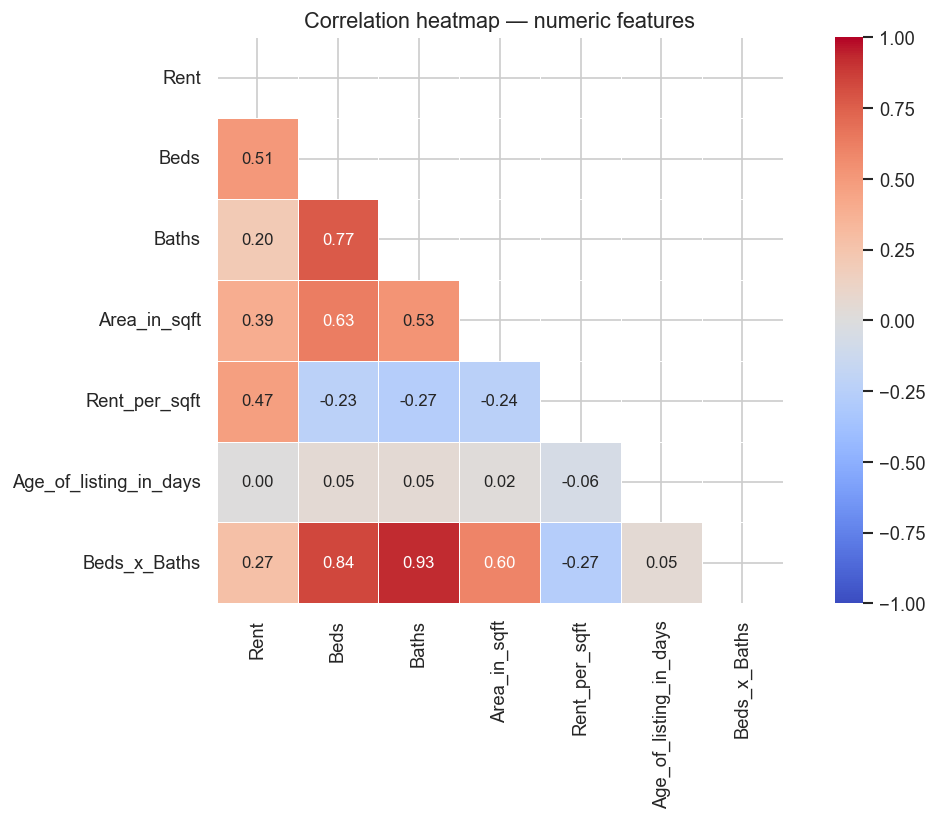

In [13]:
numeric_cols = ['Rent', 'Beds', 'Baths', 'Area_in_sqft', 'Rent_per_sqft',
                'Age_of_listing_in_days', 'Beds_x_Baths']

# Only keep columns that exist in the dataframe
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle (mirror)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation heatmap — numeric features', fontsize=13)
plt.tight_layout()
plt.savefig('eda_06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [17]:
# Correlation with Rent specifically — ranked
rent_corr = corr_matrix['Rent'].drop('Rent').sort_values(key=abs, ascending=False)
print('Feature correlation with Rent (ranked by strength):')
print(rent_corr.to_frame('correlation_with_Rent'))

Feature correlation with Rent (ranked by strength):
                        correlation_with_Rent
Beds                                        1
Rent_per_sqft                               0
Area_in_sqft                                0
Beds_x_Baths                                0
Baths                                       0
Age_of_listing_in_days                      0


---
## 6. Rent per sqft by location

Rent per sqft normalises for apartment size — it shows which locations are  
genuinely more expensive per unit area vs just having bigger apartments.

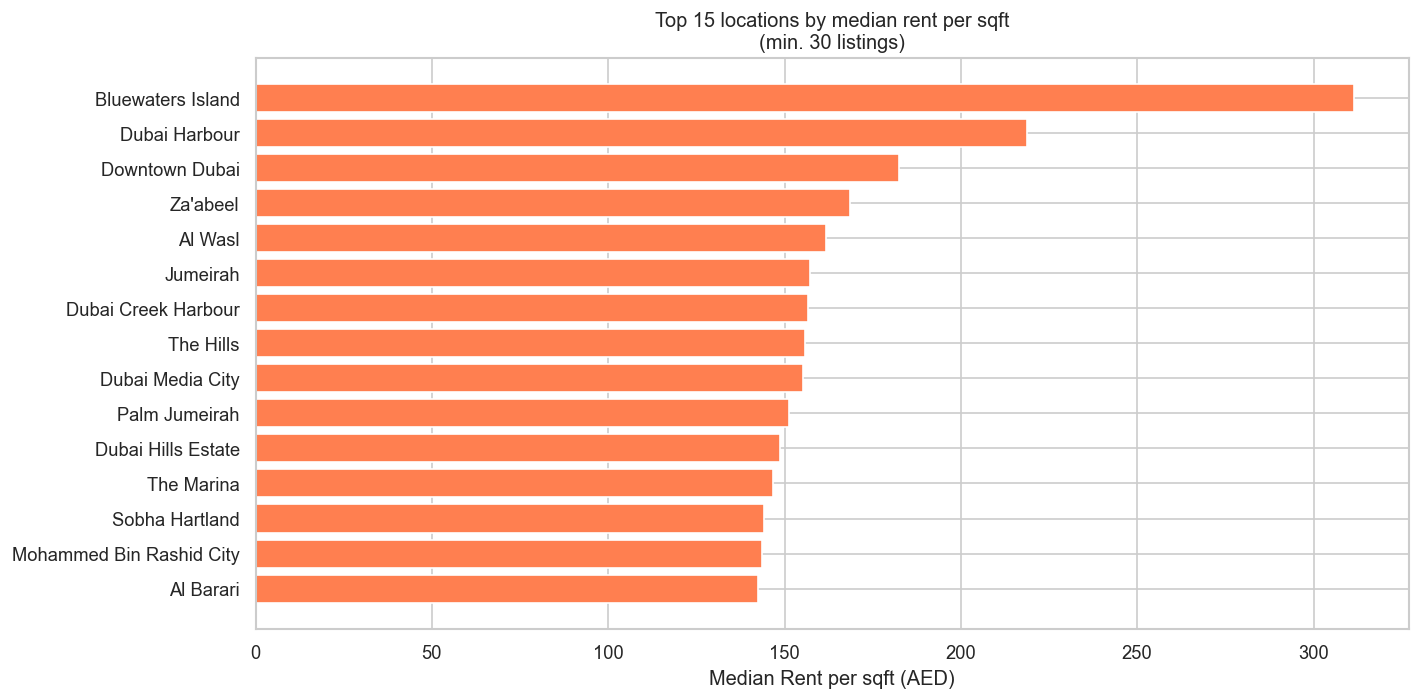

In [18]:
if 'Rent_per_sqft' in df.columns:
    rpsf_stats = (
        df.groupby('Location')['Rent_per_sqft']
        .agg(median_rpsf='median', count='count')
        .query('count >= 30')
        .sort_values('median_rpsf', ascending=False)
        .head(15)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(rpsf_stats['Location'], rpsf_stats['median_rpsf'],
            color='coral', edgecolor='white')
    ax.set_xlabel('Median Rent per sqft (AED)')
    ax.set_title('Top 15 locations by median rent per sqft\n(min. 30 listings)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('eda_07_rent_per_sqft_by_location.png', bbox_inches='tight')
    plt.show()

---
## 7. EDA summary — feature decisions for Phase 3

Based on everything above, here are the features we'll use in the model.

In [19]:
print('=== FEATURE SHORTLIST FOR PHASE 3 MODEL ===')
print()
print('TARGET:')
print('  log_Rent  (log-transformed Rent — if skewness > 1)')
print()
print('NUMERIC FEATURES:')
print('  Area_in_sqft  — strongest numeric predictor')
print('  Beds          — strong positive correlation with Rent')
print('  Baths         — correlated with Beds and Rent')
print('  Beds_x_Baths  — interaction term')
print()
print('CATEGORICAL FEATURES (will be encoded):')
print('  Location      — most powerful predictor in real estate')
print('  Furnishing    — furnished apartments command a premium')
print('  Type          — apartment sub-type affects price')
print('  Frequency     — payment frequency may affect quoted price')
print()
print('DROPPED:')
print('  Address       — too granular, Location captures this')
print('  Posted_date   — weak signal, Age_of_listing covers time')
print('  City          — all Dubai, no variance')
print('  Latitude/Longitude — Location encoding covers geography')
print()
print('Next step: 03_model.ipynb')

=== FEATURE SHORTLIST FOR PHASE 3 MODEL ===

TARGET:
  log_Rent  (log-transformed Rent — if skewness > 1)

NUMERIC FEATURES:
  Area_in_sqft  — strongest numeric predictor
  Beds          — strong positive correlation with Rent
  Baths         — correlated with Beds and Rent
  Beds_x_Baths  — interaction term

CATEGORICAL FEATURES (will be encoded):
  Location      — most powerful predictor in real estate
  Furnishing    — furnished apartments command a premium
  Type          — apartment sub-type affects price
  Frequency     — payment frequency may affect quoted price

DROPPED:
  Address       — too granular, Location captures this
  Posted_date   — weak signal, Age_of_listing covers time
  City          — all Dubai, no variance
  Latitude/Longitude — Location encoding covers geography

Next step: 03_model.ipynb


In [ ]:
# Save the dataframe with log_Rent added — use this as input for Phase 3
CLEAN_PATH_V2 = r'C:\Users\ashly\Real Estate Predictor\dubai_clean.csv'
df.to_csv(CLEAN_PATH_V2, index=False)
print(f'Updated dataset saved (with log_Rent column): {df.shape}')